# Entrenamiento del Modelo de Detección de Fraude

Este cuaderno detalla el proceso de preprocesamiento, entrenamiento, evaluación y exportación del modelo de detección de fraude.

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import os

# Configuración
data_path = '../data/financial_fraud_detection_dataset.csv'
model_path = '../model/fraud_model.joblib'

## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv(data_path)

# Selección de características relevantes
features = ['amount', 'transaction_type', 'merchant_category', 'device_used', 
            'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel']
target = 'is_fraud'

X = df[features]
y = df[target].astype(int) # True/False a 1/0

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (4000000, 8), Prueba: (1000000, 8)


## 2. Creación del Pipeline de Preprocesamiento y Modelo

In [3]:
# Definir preprocesamiento para variables numéricas y categóricas
numeric_features = ['amount', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score']
categorical_features = ['transaction_type', 'merchant_category', 'device_used', 'payment_channel']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Crear el pipeline completo con el clasificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

## 3. Entrenamiento

In [4]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amount',
                                                   'spending_deviation_score',
                                                   'velocity_score',
                                                   'geo_anomaly_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'device_used',
                                                   'payment_channel'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

## 4. Evaluación

In [5]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    964089
           1       0.05      0.00      0.00     35911

    accuracy                           0.96   1000000
   macro avg       0.51      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000

ROC AUC Score: 0.5004


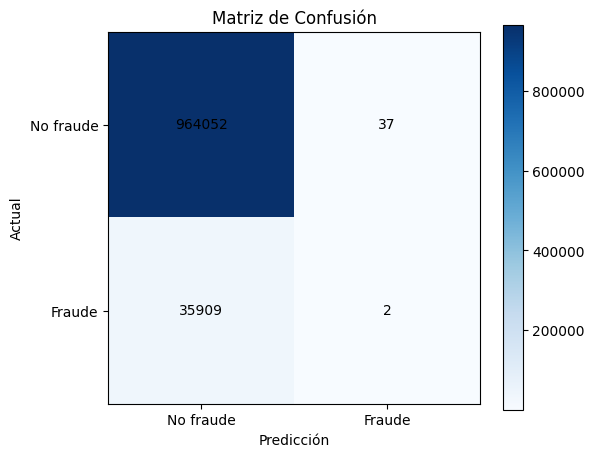

In [7]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_title('Matriz de Confusión')
ax.set_xlabel('Predicción')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No fraude', 'Fraude'])
ax.set_yticklabels(['No fraude', 'Fraude'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=ax)
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import warnings

warnings.filterwarnings("ignore")

param_distributions = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', 0.5]
}

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(random_search.best_params_)
print(f"Mejor ROC AUC en validación: {random_search.best_score_:.4f}")

model_pipeline = random_search.best_estimator_

y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print(f"ROC AUC en prueba: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=4, classifier__min_samples_split=10, classifier__n_estimators=100; total time=19.9min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=4, classifier__min_samples_split=10, classifier__n_estimators=100; total time=19.3min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=4, classifier__min_samples_split=10, classifier__n_estimators=100; total time=21.8min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=10, classifier__n_estimators=100; total time=18.3min


## 5. Guardar el Modelo

In [ ]:
# Crear carpeta si no existe (aunque ya debería estar creada)
os.makedirs(os.path.dirname(model_path), exist_ok=True)

joblib.dump(model_pipeline, model_path)
print(f"Modelo guardado exitosamente en: {model_path}")

Modelo guardado exitosamente en: ../model/fraud_model.joblib
